특성데이터: 가격을 제외한 나머지
라벨: 가격

1. 상관관계를 구하시요
2. train, test 분할
2. 라벨: 가격분류 특성데이터: 가격분류제외 나머지
3. 3065	2015	중형	13.8	200	44.5	디젤	0	2199	1799	자동 : 가격분류 예측하시요
4. train, test  : confusion matrix, 정확도, 정밀도, 재현율, f1 score , roc 를 구하시요

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder, OrdinalEncoder, LabelEncoder
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family']='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

hDF = pd.read_excel('현대자동차.xlsx')
hDF.head(5)

,가격,년식,종류,연비,마력,토크,연료,하이브리드,배기량,중량,변속기,가격분류
0,1885,2015,준중형,11.8,172,21.0,가솔린,0,1999,1300,자동,일반
1,2190,2015,준중형,12.3,204,27.0,가솔린,0,1591,1300,자동,고가
2,1135,2015,소형,15.0,100,13.6,가솔린,0,1368,1035,수동,일반
3,1645,2014,소형,14.0,140,17.0,가솔린,0,1591,1090,자동,일반
4,1960,2015,대형,9.6,175,46.0,디젤,0,2497,1990,자동,일반


In [2]:
x_data = hDF.iloc[:,:-1]
y_data = hDF.iloc[:,-1]

In [3]:
# train, test 나누기

x_train, x_test, y_train, y_test = train_test_split(
                                    x_data, y_data, test_size=0.3, stratify=y_data)

In [4]:
encodeL = LabelEncoder()

y_train_encode = encodeL.fit_transform(y_train)
y_test_encode = encodeL.fit_transform(y_test)

m_list = [('enc', OneHotEncoder(),['종류','연료','변속기']),
          ('scale', StandardScaler(),['가격','년식','연비','마력','토크','배기량','중량'])]
h_preprocessor = ColumnTransformer(m_list,
                                   remainder='passthrough')
h_pipe = Pipeline([('ct',h_preprocessor),
                   ('logic', LogisticRegression(max_iter=500))])

h_pipe.fit(x_train, y_train_encode)

# train 예측
train_pred = h_pipe.predict(x_train)
# test 예측
test_pred = h_pipe.predict(x_test)

In [5]:
# 3065	2015	중형	13.8	200	44.5	디젤	0	2199	1799	자동 : 가격분류 예측하시요
frame_d = pd.DataFrame({
    '가격':[3065],'년식':[2015],'종류':['중형'],'연비':[13.8],'마력':[200],
    '토크':[44.5],'연료':['디젤'],'하이브리드':[0],'배기량':[2199],
    '중량':[1799],'변속기':['자동']})
h_pipe.predict(frame_d)
pred_label = encodeL.inverse_transform(h_pipe.predict(frame_d))
pred_label

array(['고가'], dtype=object)

In [6]:
# 상관관계
df_e = pd.get_dummies(hDF)
df_e.corr().head(5)

,가격,년식,연비,마력,토크,하이브리드,배기량,중량,종류_대형,종류_소형,종류_준중형,종류_중형,연료_LPG,연료_가솔린,연료_디젤,변속기_수동,변속기_자동,가격분류_고가,가격분류_일반
가격,1.000000,0.378237,-0.345488,0.893995,0.565016,0.043974,0.852247,0.517288,0.369239,-0.438728,-0.157510,0.175226,-0.108782,0.059893,-0.004273,-0.326464,0.326464,0.588956,-0.588956
년식,0.378237,1.000000,-0.354930,0.485245,0.538361,-0.079089,0.451284,0.569321,0.268459,-0.697305,0.162189,0.240789,-0.103639,-0.308995,0.366423,-0.181793,0.181793,0.448308,-0.448308
연비,-0.345488,-0.354930,1.000000,-0.499384,-0.260482,0.237268,-0.659503,-0.698694,-0.690840,0.473661,0.260759,0.071571,-0.376296,0.164325,0.028593,0.182552,-0.182552,-0.103280,0.103280
마력,0.893995,0.485245,-0.499384,1.000000,0.662249,-0.112834,0.909100,0.618218,0.445521,-0.562641,-0.109979,0.164217,-0.116156,0.026735,0.033106,-0.303948,0.303948,0.606549,-0.606549
토크,0.565016,0.538361,-0.260482,0.662249,1.000000,-0.191790,0.616431,0.743632,0.375717,-0.635442,-0.011317,0.223965,-0.183606,-0.559486,0.661371,-0.131063,0.131063,0.532648,-0.532648


In [7]:
# confusion matrix 구하기

train_c = confusion_matrix(y_train_encode, train_pred)
test_c = confusion_matrix(y_test_encode, test_pred)

print(train_c)
print(test_c)

[[24  2]
 [ 0 23]]
[[12  0]
 [ 0 10]]


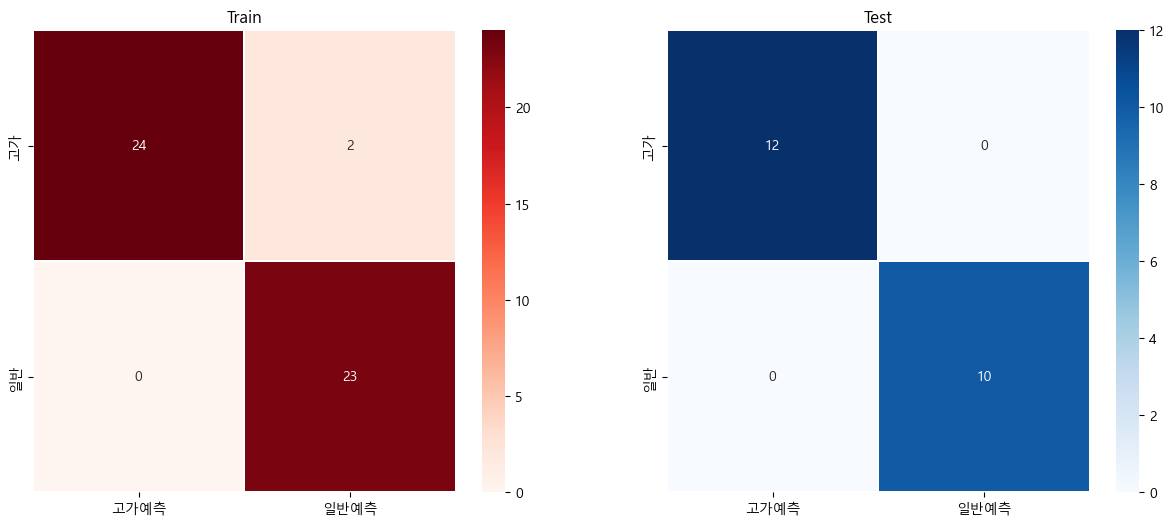

In [8]:
import seaborn as sb

# subplots : 한창에 여러차트 나타내기 좋음. 많이 사용
fig, axes = plt.subplots(1,2, figsize=[15,6])
sb.heatmap(train_c, annot=True, fmt='d',
           linewidths=0.2, cmap = 'Reds',
           xticklabels=['고가예측','일반예측'],
           yticklabels=['고가', '일반'], label='Test', ax=axes[0])
axes[0].set_title('Train')
sb.heatmap(test_c, annot=True, fmt='d',
           linewidths=0.2, cmap = 'Blues',
           xticklabels=['고가예측','일반예측'],
           yticklabels=['고가', '일반'], label='Test', ax=axes[1])
axes[1].set_title('Test')
plt.show()

In [9]:
# 정확도, 정말도, 재현율, f1 score
print('===================== train ======================')
print('정확도    : ', accuracy_score(y_train_encode, train_pred))
print('정밀도    : ', precision_score(y_train_encode, train_pred))
print('재현율    : ', recall_score(y_train_encode, train_pred))
print('f1 score : ', f1_score(y_train_encode, train_pred))
print('===================== test ======================')
print('정확도    : ', accuracy_score(y_test_encode, test_pred))
print('정밀도    : ', precision_score(y_test_encode, test_pred))
print('재현율    : ', recall_score(y_test_encode, test_pred))
print('f1 score : ', f1_score(y_test_encode, test_pred))

===================== train ======================
정확도    :  0.9591836734693877
정밀도    :  0.92
재현율    :  1.0
f1 score :  0.9583333333333334
===================== test ======================
정확도    :  1.0
정밀도    :  1.0
재현율    :  1.0
f1 score :  1.0


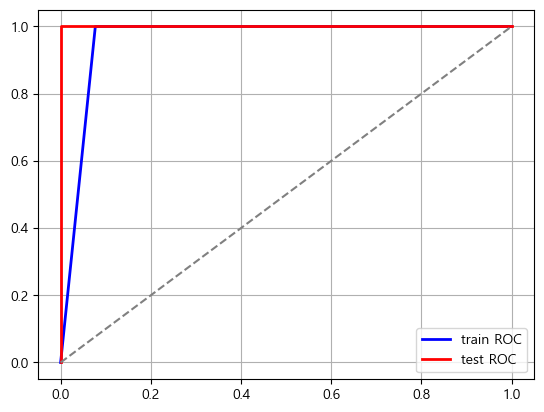

In [10]:
# roc를 구하시오
fpr, tpr, thresholds = roc_curve(y_train_encode, train_pred)
tfpr, ttpr, tthresholds = roc_curve(y_test_encode, test_pred)
train_auc = auc(fpr, tpr)
test_auc = auc(tfpr, ttpr)

plt.plot(fpr, tpr, color='blue', lw=2, label='train ROC')
plt.plot(tfpr, ttpr, color='red', lw=2, label='test ROC')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.grid(True)
plt.legend(loc='lower right')
plt.show()

In [11]:
hDF.head(5)

,가격,년식,종류,연비,마력,토크,연료,하이브리드,배기량,중량,변속기,가격분류
0,1885,2015,준중형,11.8,172,21.0,가솔린,0,1999,1300,자동,일반
1,2190,2015,준중형,12.3,204,27.0,가솔린,0,1591,1300,자동,고가
2,1135,2015,소형,15.0,100,13.6,가솔린,0,1368,1035,수동,일반
3,1645,2014,소형,14.0,140,17.0,가솔린,0,1591,1090,자동,일반
4,1960,2015,대형,9.6,175,46.0,디젤,0,2497,1990,자동,일반
